In [ ]:
# Install library yang dibutuhkan
!pip install pyswarms imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)
from imblearn.over_sampling import SMOTE
import pyswarms as ps
import warnings
warnings.filterwarnings('ignore')

# Load dataset (separator adalah titik koma)
df = pd.read_csv('/content/winequality-white.csv', sep=';')

# Buat label biner
df['kategori_kualitas'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)
# 1 = Good (>=6), 0 = Bad (<6)

print(df.shape)
df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.6 MB/s eta 0:00:00
(4898, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,kategori_kualitas
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,1
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,1


       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    4898.000000       4898.000000  4898.000000     4898.000000   
mean        6.854788          0.278241     0.334192        6.391415   
std         0.843868          0.100795     0.121020        5.072058   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.300000          0.210000     0.270000        1.700000   
50%         6.800000          0.260000     0.320000        5.200000   
75%         7.300000          0.320000     0.390000        9.900000   
max        14.200000          1.100000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  4898.000000          4898.000000           4898.000000  4898.000000   
mean      0.045772            35.308085            138.360657     0.994027   
std       0.021848            17.007137             42.498065     0.002991   
min       0.009000             2.000000         

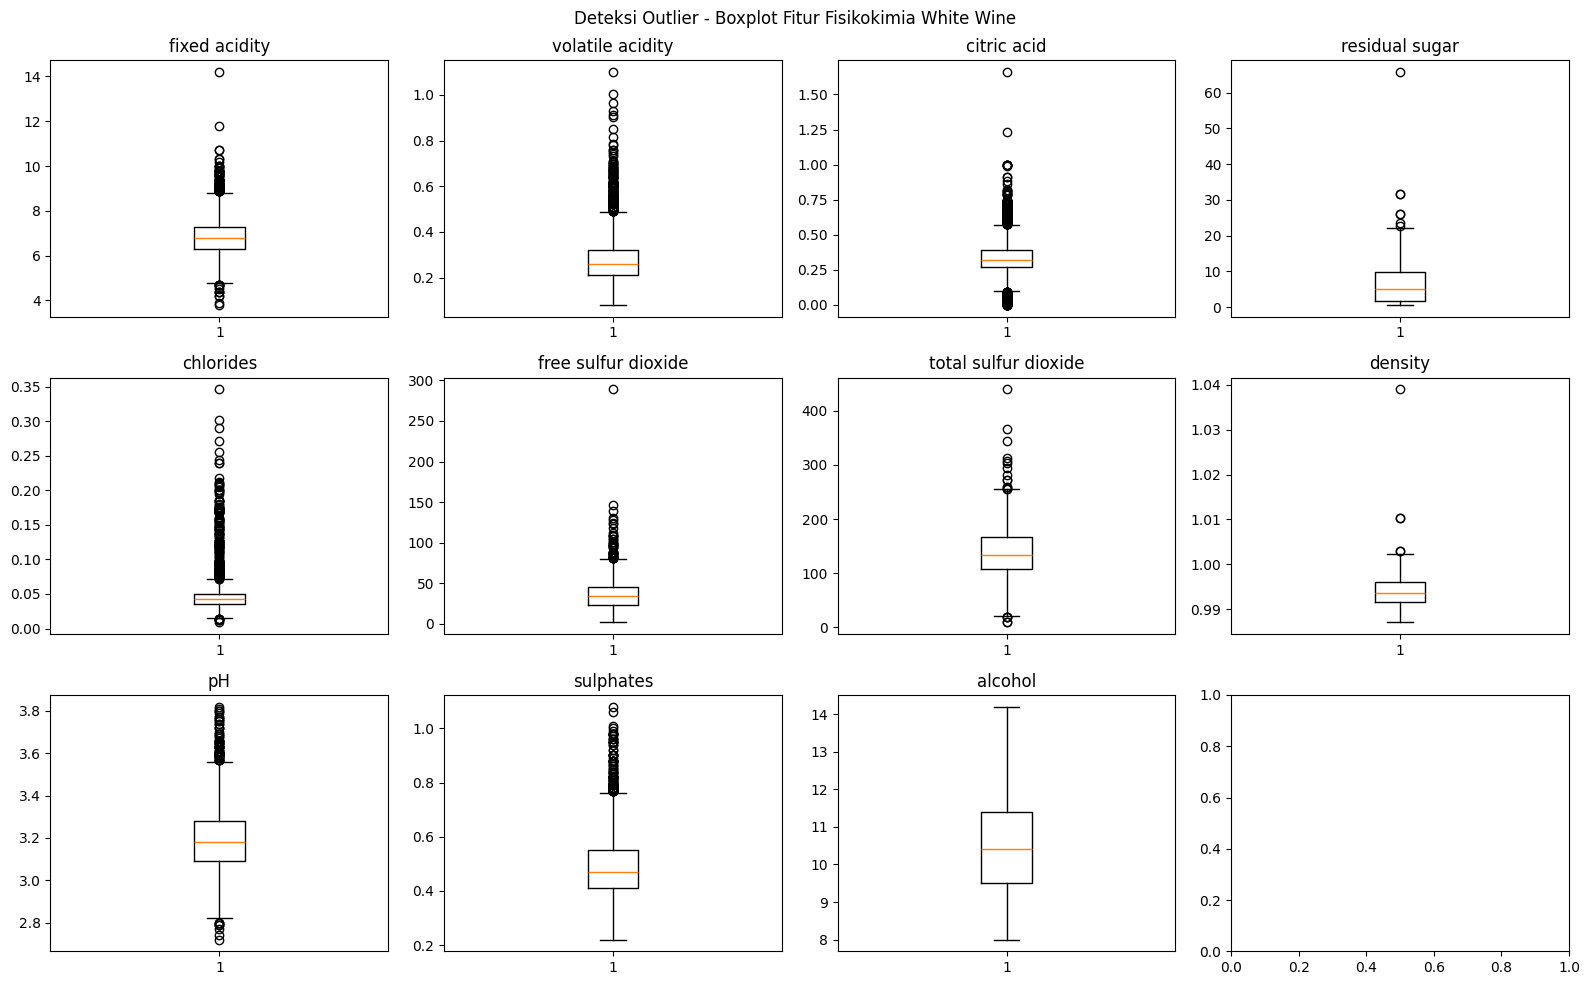

In [ ]:
# Statistik deskriptif
print(df.describe())

# Boxplot untuk deteksi outlier setiap fitur
features = df.columns[:-2]  # semua kecuali quality & kategori_kualitas
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.suptitle('Deteksi Outlier - Boxplot Fitur Fisikokimia White Wine')
plt.tight_layout()
plt.show()

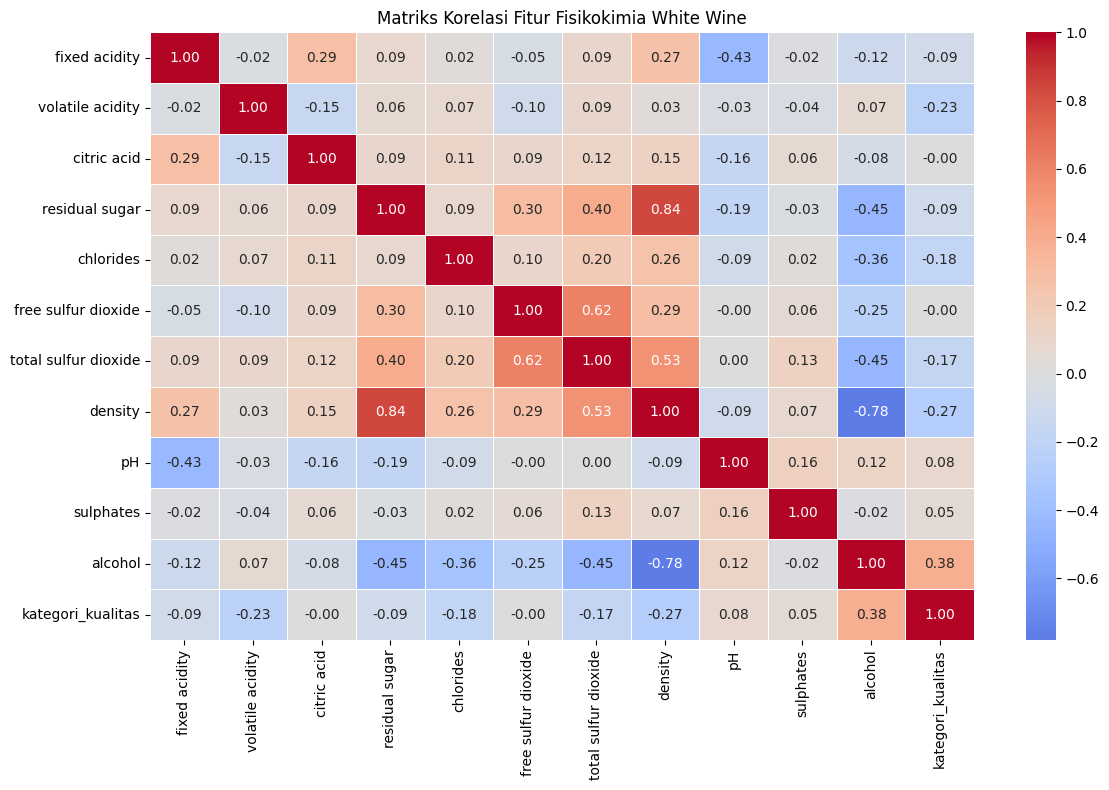

kategori_kualitas       1.000000
alcohol                 0.383280
pH                      0.083687
sulphates               0.051858
citric acid            -0.000700
free sulfur dioxide    -0.001278
fixed acidity          -0.089749
residual sugar         -0.092756
total sulfur dioxide   -0.170924
chlorides              -0.183939
volatile acidity       -0.225440
density                -0.268696
Name: kategori_kualitas, dtype: float64


In [ ]:
# Heatmap korelasi antar fitur
plt.figure(figsize=(12, 8))
corr_matrix = df[list(features) + ['kategori_kualitas']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, center=0)
plt.title('Matriks Korelasi Fitur Fisikokimia White Wine')
plt.tight_layout()
plt.show()

# Korelasi dengan target
print(corr_matrix['kategori_kualitas'].sort_values(ascending=False))

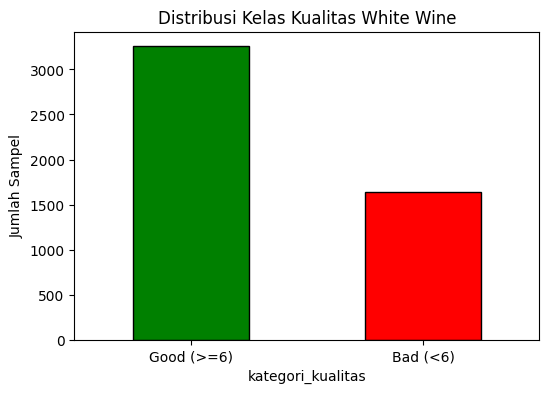

kategori_kualitas
1    3258
0    1640
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(6,4))
df['kategori_kualitas'].value_counts().plot(kind='bar',
    color=['green','red'], edgecolor='black')
plt.xticks([0,1], ['Good (>=6)', 'Bad (<6)'], rotation=0)
plt.title('Distribusi Kelas Kualitas White Wine')
plt.ylabel('Jumlah Sampel')
plt.show()

print(df['kategori_kualitas'].value_counts())

In [ ]:
# Pisahkan fitur dan target
X = df.drop(['quality', 'kategori_kualitas'], axis=1)
y = df['kategori_kualitas']

# Hapus fitur 'density' seperti yang diminta
print(f"Bentuk fitur sebelum menghapus 'density': {X.shape}")
X = X.drop('density', axis=1)
print(f"Bentuk fitur setelah menghapus 'density': {X.shape}")

# Split data SEBELUM SMOTE (penting! SMOTE hanya pada training set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribusi train sebelum SMOTE:\n{y_train.value_counts()}")

# Feature Scaling menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit hanya di train
X_test_scaled = scaler.transform(X_test)         # transform di test

# SMOTE hanya pada training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nDistribusi train SETELAH SMOTE:\n{pd.Series(y_train_resampled).value_counts()}")

Bentuk fitur sebelum menghapus 'density': (4898, 11)
Bentuk fitur setelah menghapus 'density': (4898, 10)

Train: (3918, 10), Test: (980, 10)
Distribusi train sebelum SMOTE:
kategori_kualitas
1    2606
0    1312
Name: count, dtype: int64

Distribusi train SETELAH SMOTE:
kategori_kualitas
1    2606
0    2606
Name: count, dtype: int64


In [ ]:
# Model baseline dengan hyperparameter default
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_resampled, y_train_resampled)

y_pred_baseline = rf_baseline.predict(X_test_scaled)
y_prob_baseline = rf_baseline.predict_proba(X_test_scaled)[:, 1]

print("=== BASELINE MODEL (Tanpa PSO) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_baseline):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob_baseline):.4f}")

=== BASELINE MODEL (Tanpa PSO) ===
Accuracy : 0.8347
Precision: 0.8901
Recall   : 0.8574
F1-Score : 0.8734
AUC      : 0.9071


In [ ]:
from pyswarms.single.global_best import GlobalBestPSO

# Definisikan fungsi objektif untuk PSO
def rf_pso_objective(params):
    """
    PSO meminimalkan fungsi ini,
    jadi kita return 1 - F1 agar PSO mencari F1 maksimal
    """
    scores = []
    for p in params:
        # Decode parameter dari continuous ke valid hyperparameter
        n_estimators   = int(np.clip(p[0], 50, 300))
        max_depth       = int(np.clip(p[1], 2, 20))
        min_samples_split = int(np.clip(p[2], 2, 20))
        min_samples_leaf  = int(np.clip(p[3], 1, 10))
        max_features_idx  = int(np.clip(p[4], 0, 1))
        max_features_opt  = ['sqrt', 'log2'][max_features_idx]

        clf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features_opt,
            random_state=42,
            n_jobs=-1
        )

        # Gunakan cross-validation di training data
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(clf, X_train_resampled, y_train_resampled,
                                cv=cv, scoring='f1').mean()
        scores.append(1 - score)  # minimasi, jadi 1 - F1

    return np.array(scores)

# Definisikan batas bawah dan atas setiap dimensi hyperparameter
lb = [50,  2,  2, 1, 0]
ub = [300, 20, 20, 10, 1]

# Konfigurasi PSO
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

optimizer = GlobalBestPSO(
    n_particles=10,   # jumlah partikel
    dimensions=5,     # jumlah hyperparameter yang dioptimasi
    options=options,
    bounds=(lb, ub)
)

# Jalankan PSO
best_cost, best_pos = optimizer.optimize(rf_pso_objective, iters=15)

print("\n=== HASIL OPTIMASI PSO ===")
print(f"Best Cost (1-F1): {best_cost:.4f}")
print(f"Best F1 Score   : {1 - best_cost:.4f}")
print(f"\nHyperparameter Terbaik:")
print(f"  n_estimators     : {int(np.clip(best_pos[0], 50, 300))}")
print(f"  max_depth        : {int(np.clip(best_pos[1], 2, 20))}")
print(f"  min_samples_split: {int(np.clip(best_pos[2], 2, 20))}")
print(f"  min_samples_leaf : {int(np.clip(best_pos[3], 1, 10))}")
print(f"  max_features     : {['sqrt','log2'][int(np.clip(best_pos[4], 0, 1))]}")

2026-04-12 00:28:07,116 - pyswarms.single.global_best - INFO - Optimize for 15 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|15/15, best_cost=0.128
2026-04-12 00:49:10,666 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.12806105072448837, best pos: [192.47399059  17.76551268   2.6259851    1.56823876   0.25150383]



=== HASIL OPTIMASI PSO ===
Best Cost (1-F1): 0.1281
Best F1 Score   : 0.8719

Hyperparameter Terbaik:
  n_estimators     : 192
  max_depth        : 17
  min_samples_split: 2
  min_samples_leaf : 1
  max_features     : sqrt


In [ ]:
# Bangun model dengan hyperparameter hasil PSO
best_n_estimators    = int(np.clip(best_pos[0], 50, 300))
best_max_depth       = int(np.clip(best_pos[1], 2, 20))
best_min_split       = int(np.clip(best_pos[2], 2, 20))
best_min_leaf        = int(np.clip(best_pos[3], 1, 10))
best_max_features    = ['sqrt', 'log2'][int(np.clip(best_pos[4], 0, 1))]

rf_pso = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_split,
    min_samples_leaf=best_min_leaf,
    max_features=best_max_features,
    random_state=42,
    n_jobs=-1
)

rf_pso.fit(X_train_resampled, y_train_resampled)

y_pred_pso = rf_pso.predict(X_test_scaled)
y_prob_pso = rf_pso.predict_proba(X_test_scaled)[:, 1]

print("=== MODEL DENGAN PSO ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_pso):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_pso):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_pso):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_pso):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob_pso):.4f}")
print()
print(classification_report(y_test, y_pred_pso,
      target_names=['Bad (<6)', 'Good (>=6)']))

=== MODEL DENGAN PSO ===
Accuracy : 0.8418
Precision: 0.8913
Recall   : 0.8681
F1-Score : 0.8796
AUC      : 0.9075

              precision    recall  f1-score   support

    Bad (<6)       0.75      0.79      0.77       328
  Good (>=6)       0.89      0.87      0.88       652

    accuracy                           0.84       980
   macro avg       0.82      0.83      0.82       980
weighted avg       0.84      0.84      0.84       980



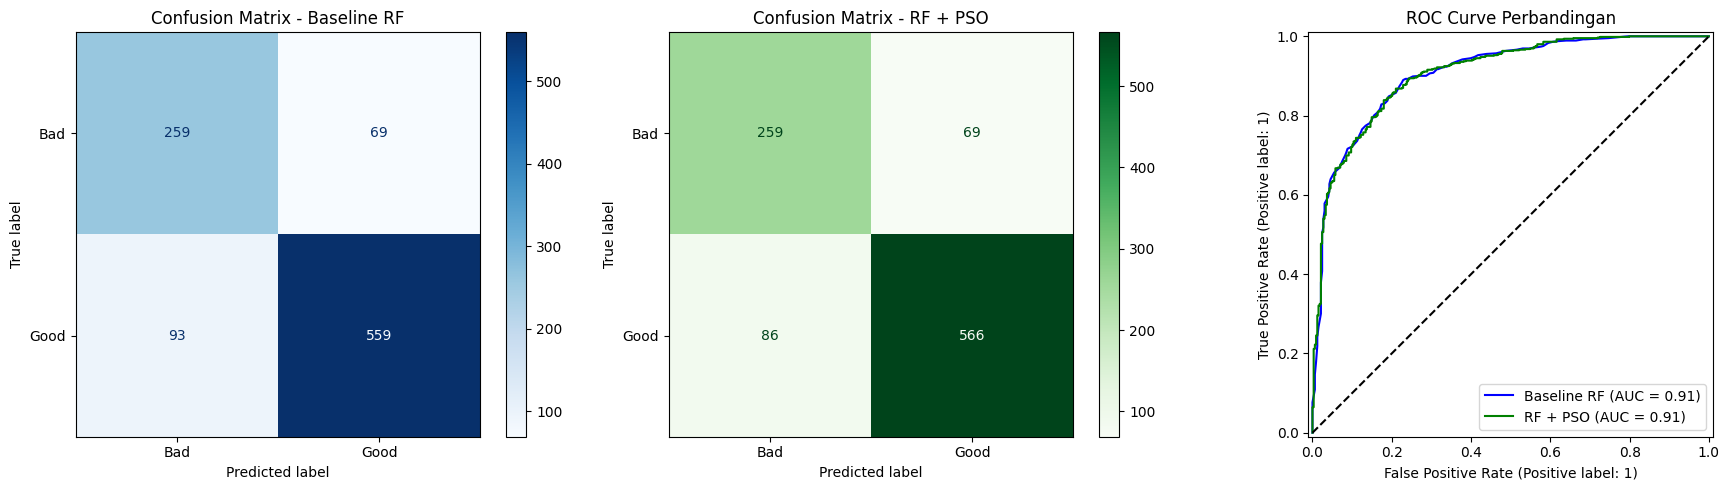

           Baseline RF  RF + PSO
Metrik                          
Accuracy        0.8347    0.8418
Precision       0.8901    0.8913
Recall          0.8574    0.8681
F1-Score        0.8734    0.8796
AUC             0.9071    0.9075


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix Baseline
cm_base = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(cm_base, display_labels=['Bad','Good']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Baseline RF')

# 2. Confusion Matrix PSO
cm_pso = confusion_matrix(y_test, y_pred_pso)
ConfusionMatrixDisplay(cm_pso, display_labels=['Bad','Good']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Confusion Matrix - RF + PSO')

# 3. ROC Curve Perbandingan
RocCurveDisplay.from_predictions(y_test, y_prob_baseline,
    name='Baseline RF', ax=axes[2], color='blue')
RocCurveDisplay.from_predictions(y_test, y_prob_pso,
    name='RF + PSO', ax=axes[2], color='green')
axes[2].set_title('ROC Curve Perbandingan')
axes[2].plot([0,1],[0,1], 'k--')

plt.tight_layout()
plt.show()

# Tabel Perbandingan Metrik
metrics = {
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Baseline RF': [
        accuracy_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_baseline),
        roc_auc_score(y_test, y_prob_baseline)
    ],
    'RF + PSO': [
        accuracy_score(y_test, y_pred_pso),
        precision_score(y_test, y_pred_pso),
        recall_score(y_test, y_pred_pso),
        f1_score(y_test, y_pred_pso),
        roc_auc_score(y_test, y_prob_pso)
    ]
}
df_metrics = pd.DataFrame(metrics)
df_metrics = df_metrics.set_index('Metrik')
print(df_metrics.round(4))

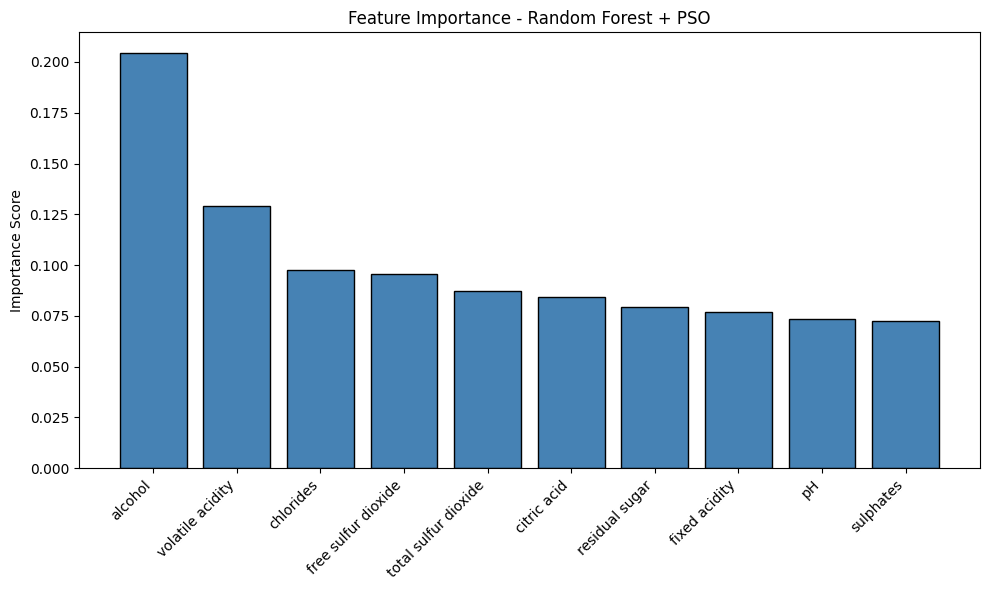


Ranking Fitur:
  1. alcohol                   : 0.2044
  2. volatile acidity          : 0.1292
  3. chlorides                 : 0.0975
  4. free sulfur dioxide       : 0.0956
  5. total sulfur dioxide      : 0.0870
  6. citric acid               : 0.0841
  7. residual sugar            : 0.0795
  8. fixed acidity             : 0.0768
  9. pH                        : 0.0734
  10. sulphates                 : 0.0725


In [ ]:
feature_names = X.columns
importances = rf_pso.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_names)), importances[indices], color='steelblue', edgecolor='black')
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance - Random Forest + PSO')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nRanking Fitur:")
for rank, i in enumerate(indices, 1):
    print(f"  {rank}. {feature_names[i]:<25} : {importances[i]:.4f}")

**COBA BALANCING PAKE CLASS WEIGHT**

In [ ]:
# Pisahkan fitur dan target
X = df.drop(['quality', 'kategori_kualitas'], axis=1)
y = df['kategori_kualitas']

# Hapus fitur 'density' seperti yang diminta
print(f"Bentuk fitur sebelum menghapus 'density': {X.shape}")
X = X.drop('density', axis=1)
print(f"Bentuk fitur setelah menghapus 'density': {X.shape}")

# Split data SEBELUM balancing (penting! balancing hanya pada training set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribusi train sebelum balancing:\n{y_train.value_counts()}")

# Feature Scaling menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit hanya di train
X_test_scaled = scaler.transform(X_test)         # transform di test

# Dengan class_weight, kita tidak perlu resampling. Langsung gunakan data yang diskalakan.
print("\nMenggunakan class_weight='balanced' untuk menangani data imbalance.")

Bentuk fitur sebelum menghapus 'density': (4898, 11)
Bentuk fitur setelah menghapus 'density': (4898, 10)

Train: (3918, 10), Test: (980, 10)
Distribusi train sebelum balancing:
kategori_kualitas
1    2606
0    1312
Name: count, dtype: int64

Menggunakan class_weight='balanced' untuk menangani data imbalance.


In [ ]:
# Model baseline dengan hyperparameter default
rf_baseline = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_baseline.fit(X_train_scaled, y_train)

y_pred_baseline = rf_baseline.predict(X_test_scaled)
y_prob_baseline = rf_baseline.predict_proba(X_test_scaled)[:, 1]

print("=== BASELINE MODEL (Tanpa PSO) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_baseline):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob_baseline):.4f}")

=== BASELINE MODEL (Tanpa PSO) ===
Accuracy : 0.8449
Precision: 0.8623
Recall   : 0.9126
F1-Score : 0.8867
AUC      : 0.9081


In [ ]:
from pyswarms.single.global_best import GlobalBestPSO

# Definisikan fungsi objektif untuk PSO
def rf_pso_objective(params):
    """
    PSO meminimalkan fungsi ini,
    jadi kita return 1 - F1 agar PSO mencari F1 maksimal
    """
    scores = []
    for p in params:
        # Decode parameter dari continuous ke valid hyperparameter
        n_estimators   = int(np.clip(p[0], 50, 300))
        max_depth       = int(np.clip(p[1], 2, 20))
        min_samples_split = int(np.clip(p[2], 2, 20))
        min_samples_leaf  = int(np.clip(p[3], 1, 10))
        max_features_idx  = int(np.clip(p[4], 0, 1))
        max_features_opt  = ['sqrt', 'log2'][max_features_idx]

        clf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features_opt,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        )

        # Gunakan cross-validation di training data
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(clf, X_train_scaled, y_train,
                                cv=cv, scoring='f1').mean()
        scores.append(1 - score)  # minimasi, jadi 1 - F1

    return np.array(scores)

# Definisikan batas bawah dan atas setiap dimensi hyperparameter
lb = [50,  2,  2, 1, 0]
ub = [300, 20, 20, 10, 1]

# Konfigurasi PSO
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

optimizer = GlobalBestPSO(
    n_particles=10,   # jumlah partikel
    dimensions=5,     # jumlah hyperparameter yang dioptimasi
    options=options,
    bounds=(lb, ub)
)

# Jalankan PSO
best_cost, best_pos = optimizer.optimize(rf_pso_objective, iters=15)

print("\n=== HASIL OPTIMASI PSO ===")
print(f"Best Cost (1-F1): {best_cost:.4f}")
print(f"Best F1 Score   : {1 - best_cost:.4f}")
print(f"\nHyperparameter Terbaik:")
print(f"  n_estimators     : {int(np.clip(best_pos[0], 50, 300))}")
print(f"  max_depth        : {int(np.clip(best_pos[1], 2, 20))}")
print(f"  min_samples_split: {int(np.clip(best_pos[2], 2, 20))}")
print(f"  min_samples_leaf : {int(np.clip(best_pos[3], 1, 10))}")
print(f"  max_features     : {['sqrt','log2'][int(np.clip(best_pos[4], 0, 1))]}")

2026-04-12 01:14:30,454 - pyswarms.single.global_best - INFO - Optimize for 15 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|15/15, best_cost=0.12
2026-04-12 01:31:18,775 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.12007378175286942, best pos: [245.54895394  15.8886462    3.2527979    1.92733505   0.27575799]



=== HASIL OPTIMASI PSO ===
Best Cost (1-F1): 0.1201
Best F1 Score   : 0.8799

Hyperparameter Terbaik:
  n_estimators     : 245
  max_depth        : 15
  min_samples_split: 3
  min_samples_leaf : 1
  max_features     : sqrt


In [ ]:
# Bangun model dengan hyperparameter hasil PSO
best_n_estimators    = int(np.clip(best_pos[0], 50, 300))
best_max_depth       = int(np.clip(best_pos[1], 2, 20))
best_min_split       = int(np.clip(best_pos[2], 2, 20))
best_min_leaf        = int(np.clip(best_pos[3], 1, 10))
best_max_features    = ['sqrt', 'log2'][int(np.clip(best_pos[4], 0, 1))]

rf_pso = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_split,
    min_samples_leaf=best_min_leaf,
    max_features=best_max_features,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_pso.fit(X_train_scaled, y_train)

y_pred_pso = rf_pso.predict(X_test_scaled)
y_prob_pso = rf_pso.predict_proba(X_test_scaled)[:, 1]

print("=== MODEL DENGAN PSO ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_pso):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_pso):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_pso):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_pso):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob_pso):.4f}")
print()
print(classification_report(y_test, y_pred_pso,
      target_names=['Bad (<6)', 'Good (>=6)']))

=== MODEL DENGAN PSO ===
Accuracy : 0.8449
Precision: 0.8731
Recall   : 0.8972
F1-Score : 0.8850
AUC      : 0.9020

              precision    recall  f1-score   support

    Bad (<6)       0.78      0.74      0.76       328
  Good (>=6)       0.87      0.90      0.89       652

    accuracy                           0.84       980
   macro avg       0.83      0.82      0.82       980
weighted avg       0.84      0.84      0.84       980



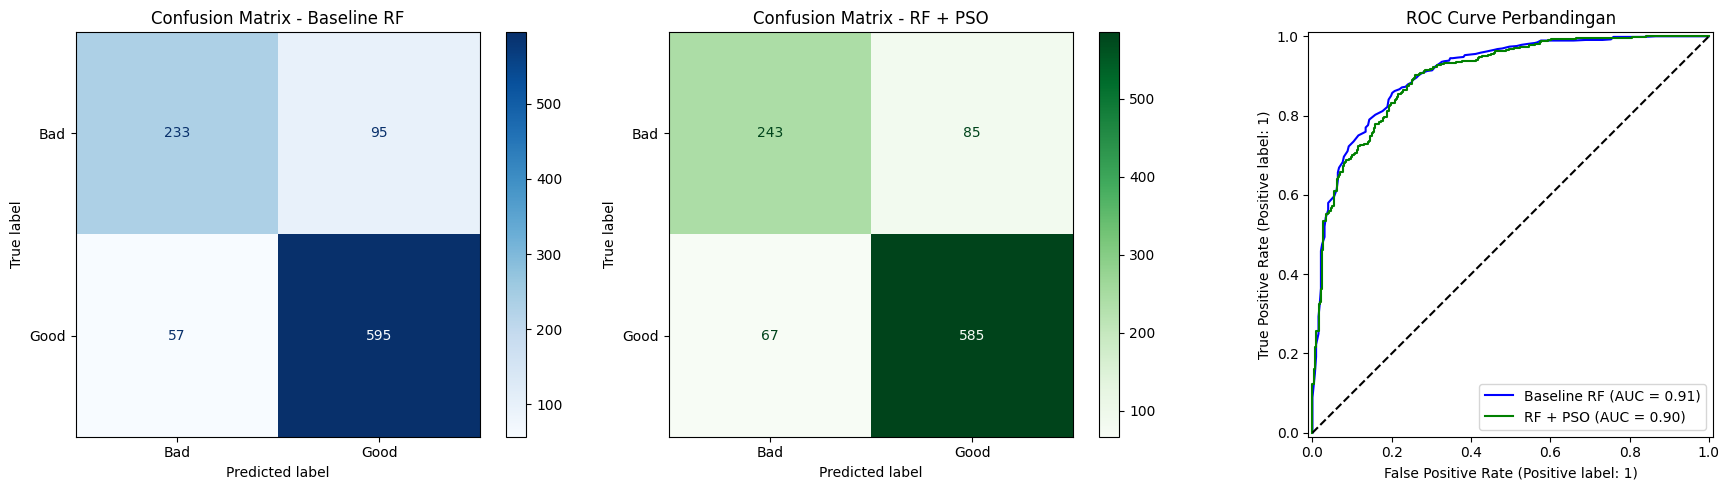

           Baseline RF  RF + PSO
Metrik                          
Accuracy        0.8449    0.8449
Precision       0.8623    0.8731
Recall          0.9126    0.8972
F1-Score        0.8867    0.8850
AUC             0.9081    0.9020


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix Baseline
cm_base = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(cm_base, display_labels=['Bad','Good']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Baseline RF')

# 2. Confusion Matrix PSO
cm_pso = confusion_matrix(y_test, y_pred_pso)
ConfusionMatrixDisplay(cm_pso, display_labels=['Bad','Good']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Confusion Matrix - RF + PSO')

# 3. ROC Curve Perbandingan
RocCurveDisplay.from_predictions(y_test, y_prob_baseline,
    name='Baseline RF', ax=axes[2], color='blue')
RocCurveDisplay.from_predictions(y_test, y_prob_pso,
    name='RF + PSO', ax=axes[2], color='green')
axes[2].set_title('ROC Curve Perbandingan')
axes[2].plot([0,1],[0,1], 'k--')

plt.tight_layout()
plt.show()

# Tabel Perbandingan Metrik
metrics = {
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Baseline RF': [
        accuracy_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_baseline),
        roc_auc_score(y_test, y_prob_baseline)
    ],
    'RF + PSO': [
        accuracy_score(y_test, y_pred_pso),
        precision_score(y_test, y_pred_pso),
        recall_score(y_test, y_pred_pso),
        f1_score(y_test, y_pred_pso),
        roc_auc_score(y_test, y_prob_pso)
    ]
}
df_metrics = pd.DataFrame(metrics)
df_metrics = df_metrics.set_index('Metrik')
print(df_metrics.round(4))

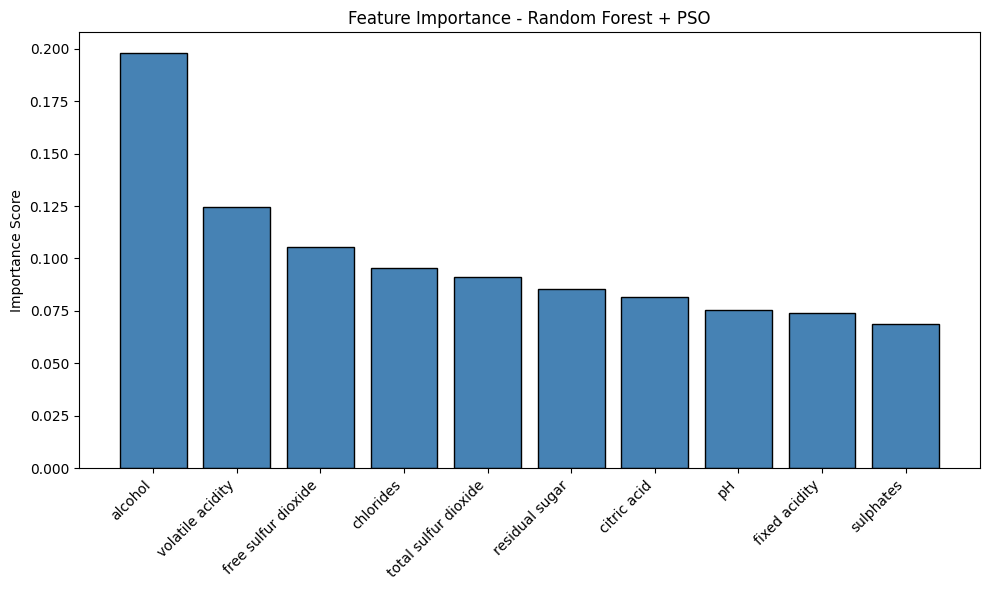


Ranking Fitur:
  1. alcohol                   : 0.1979
  2. volatile acidity          : 0.1245
  3. free sulfur dioxide       : 0.1055
  4. chlorides                 : 0.0957
  5. total sulfur dioxide      : 0.0913
  6. residual sugar            : 0.0856
  7. citric acid               : 0.0816
  8. pH                        : 0.0756
  9. fixed acidity             : 0.0738
  10. sulphates                 : 0.0686


In [ ]:
feature_names = X.columns
importances = rf_pso.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_names)), importances[indices], color='steelblue', edgecolor='black')
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance - Random Forest + PSO')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nRanking Fitur:")
for rank, i in enumerate(indices, 1):
    print(f"  {rank}. {feature_names[i]:<25} : {importances[i]:.4f}")